# ⚡ Pipeline de *Forecasting* Neural — Allen Visual Coding · Neuropixels (DANDI:000021)
### `03_hackathon_forecasting_pipeline` · NeuroDataReHack 2026

Este notebook construye, paso a paso, un **pipeline de predicción del estado neuronal** de la corteza visual primaria (**VISp**) de ratón, usando datos reales del *Allen Institute – Visual Coding – Neuropixels* (`DANDI:000021`). Los datos se leen por **streaming** desde la nube: aunque cada sesión pesa varios GB, **no descargamos el archivo entero**, solo los trozos que pedimos.

Está pensado para leerse de arriba abajo. Cada sección tiene primero una **explicación conceptual** y luego **código muy comentado** (casi línea a línea), porque usaremos varias librerías especializadas que quizá no conozcas todavía.

### 🎯 Las dos preguntas científicas

1. **¿Es predecible la dinámica de la población neuronal?** — *Forecasting autoregresivo* (Tarea A): dado el estado neuronal reciente, ¿podemos anticipar el estado **futuro** a distintos horizontes de tiempo?
2. **¿Cuánto del estado neuronal explica el *arousal* (nivel de alerta)?** — *Decoding* desde la **pupila** (Tarea B): el tamaño de la pupila es un proxy clásico del estado interno del animal. ¿Podemos reconstruir el estado neuronal **actual** mirando solo la pupila?

### 🧰 Las librerías que vamos a usar (y para qué sirve cada una)

| Librería | Para qué la usamos | Idea en una frase |
|---|---|---|
| **`pynwb` + `remfile` + `h5py`** | Leer el archivo NWB remoto por streaming | Abrir datos de neurociencia en la nube sin descargarlos |
| **`pynapple`** | Cargar y **alinear** spikes y pupila en el tiempo | "pandas para series temporales de neurociencia" |
| **`scikit-learn`** | PCA (reducción de dimensión) y métricas | Caja de herramientas estándar de *machine learning* |
| **`tsfel`** | Extraer *features* (características) de la pupila | "Calcula automáticamente decenas de estadísticos de una señal" |
| **`nemos`** | GLM (modelo lineal generalizado) acelerado con JAX | Modelo lineal rápido y moderno, diseñado para datos neuronales |
| **`torch`** | Red neuronal recurrente (GRU) en la GPU | Aprendizaje profundo para capturar dinámica no lineal |
| **`xgboost`** | *Gradient boosting* (comparativa extra) | Modelo de árboles muy potente para tabular |

### 🗺️ Hoja de ruta (orden de ejecución)

| Paso | Contenido |
|---|---|
| **0** | Entorno, comprobación de GPU y apertura del NWB por streaming |
| **1** | Cargar y **alinear** spikes de VISp + pupila a una base temporal común (`pynapple`) |
| **2** | Reducción de dimensionalidad → **Estado Neuronal `Y`** (3 componentes principales) |
| **3** | Extraer *features* de la pupila → matriz **`X`** (`tsfel`) |
| **4** | *Forecasting*: **Tarea A** (autoregresivo) y **Tarea B** (*decoding*), con GLM, GRU y XGBoost |
| **5** | Evaluación visual: R² por horizonte y trayectorias `Y` real vs predicho |

> **⚠️ Nota de rigor (muy importante en series temporales).** **Nunca barajamos** los datos: el orden temporal es sagrado. Todos los *splits* (train/test) son **secuenciales** — el 70 % del pasado para entrenar, el 30 % del futuro para evaluar — y **todos** los ajustes (escaladores, PCA) se hacen **solo con el tramo de entrenamiento**. Si mezcláramos el futuro con el pasado, el modelo "haría trampa" (*data leakage*) y las métricas serían falsamente buenas.

---
## Paso 0 — Entorno, GPU y apertura del archivo NWB

En este primer bloque:
1. Importamos todas las librerías (con un comentario de para qué sirve cada grupo).
2. Comprobamos si hay **GPU** disponible (la red recurrente entrena mucho más rápido en GPU).
3. Fijamos **semillas aleatorias** para que los resultados sean reproducibles.
4. Definimos toda la **configuración** en una sola celda.
5. Abrimos el archivo NWB remoto.

In [11]:
# ============================================================
#  IMPORTS  (agrupados por función)
# ============================================================

# 'warnings' nos deja silenciar avisos secundarios. Algunas librerías (jax, tsfel)
# imprimen advertencias no críticas que ensucian la salida; las ocultamos.
import warnings
warnings.filterwarnings("ignore")

# --- Núcleo numérico y de datos ---
import numpy as np          # arrays y álgebra numérica (la base de todo)
import pandas as pd         # tablas (DataFrame): ideal para metadatos y resultados
import matplotlib.pyplot as plt                 # gráficos
from mpl_toolkits.mplot3d import Axes3D          # noqa: F401  -> habilita el modo 3D de matplotlib

# --- Streaming de NWB / DANDI (leer el archivo remoto sin descargarlo) ---
import h5py                 # lee ficheros HDF5 (el formato interno de NWB)
import remfile              # "abre" un archivo remoto (URL) como si fuera local
import pynwb                # interpreta el HDF5 como un objeto NWB de neurociencia
from dandi.dandiapi import DandiAPIClient        # cliente para consultar el archivo DANDI

# --- Series temporales de neurociencia ---
import pynapple as nap      # objetos especializados: spikes (TsGroup), señales (Tsd), etc.

# --- Machine Learning clásico ---
from sklearn.preprocessing import StandardScaler # estandariza (media 0, desviación 1)
from sklearn.decomposition import PCA            # análisis de componentes principales
from sklearn.metrics import r2_score             # métrica R² (bondad de la predicción)

# --- Extracción de características de series temporales ---
import tsfel               # "Time Series Feature Extraction Library"

# --- GLM acelerado con JAX (baseline moderno de neurociencia) ---
import nemos as nmo        # "NEural MOdelS": GLMs rápidos para datos neuronales

# --- Aprendizaje profundo: red recurrente (GRU) ---
import torch              # framework de deep learning (tensores + autograd + GPU)
import torch.nn as nn     # módulos de redes neuronales (capas, funciones de pérdida)

# --- Gradient boosting (comparativa) ---
from xgboost import XGBRegressor                 # modelo de árboles potenciado

# Imprimimos versiones para dejar constancia del entorno exacto usado.
print("Versiones del entorno:")
print(f"  numpy      {np.__version__}")
print(f"  pandas     {pd.__version__}")
print(f"  pynwb      {pynwb.__version__}")
print(f"  pynapple   {nap.__version__}")
print(f"  nemos      {nmo.__version__}")
print(f"  torch      {torch.__version__}")

Versiones del entorno:
  numpy      2.4.6
  pandas     3.0.3
  pynwb      4.0.0
  pynapple   0.11.3
  nemos      0.2.9
  torch      2.6.0+cu124


### 0.1 ¿Tenemos GPU?

Una **GPU** (tarjeta gráfica) acelera enormemente el entrenamiento de redes neuronales porque hace miles de multiplicaciones en paralelo. `torch` puede trabajar en **GPU** (`cuda`) o en **CPU**. Detectamos automáticamente qué hay disponible y guardamos esa elección en la variable `DEVICE`, que reutilizaremos al crear la red.

Fijamos también una **semilla** (`SEED`): los modelos usan números aleatorios (inicialización de pesos, barajado de lotes…); con una semilla fija, cada ejecución da el mismo resultado, lo que hace el trabajo **reproducible**.

In [12]:
# torch.cuda.is_available() devuelve True si hay una GPU NVIDIA utilizable.
# Creamos un objeto 'device' que le dice a torch dónde colocar los tensores y el modelo.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if DEVICE.type == "cuda":
    # get_device_name(0) = nombre de la primera GPU;  torch.version.cuda = versión de CUDA compilada.
    print(f"✅ GPU detectada: {torch.cuda.get_device_name(0)}  (CUDA {torch.version.cuda})")
else:
    print("⚠️  Sin GPU: se usará CPU (el pipeline funciona igual, solo algo más lento).")
print("Dispositivo de cómputo:", DEVICE)

# Semilla para reproducibilidad: la fijamos tanto en numpy como en torch.
SEED = 42
np.random.seed(SEED)        # controla el azar de numpy (p. ej. inicializaciones)
torch.manual_seed(SEED)     # controla el azar de torch (pesos de la red, barajado)

✅ GPU detectada: NVIDIA GeForce RTX 4070 Laptop GPU  (CUDA 12.4)
Dispositivo de cómputo: cuda


### 0.2 Configuración central

Reunimos **todos** los parámetros ajustables en una sola celda. Es una buena práctica: si quieres experimentar (ventana más larga, más épocas de entrenamiento, otra región…), cambias aquí y re-ejecutas, sin tocar el resto del código.

Cada parámetro lleva su comentario. Los valores de *binning*, suavizado y control de calidad siguen las convenciones habituales del Allen Institute para este dataset.

In [13]:
# ============================================================
#  CONFIGURACIÓN DEL PIPELINE  (edita aquí y re-ejecuta)
# ============================================================

# --- Qué datos cargar ---
DANDISET_ID    = "000021"                                          # id del dataset en DANDI
DANDI_FILEPATH = "sub-738651046/sub-738651046_ses-760693773.nwb"   # sesión concreta (la de tus notebooks)
REGION_OBJETIVO = "VISp"      # región cerebral: corteza visual primaria (acrónimo del atlas Allen)

# --- Cómo convertir spikes en tasas de disparo ---
TAMANO_BIN      = 0.050     # anchura de cada "bin" temporal, en segundos (50 ms)
SIGMA_SUAVIZADO = 0.100     # anchura del suavizado gaussiano, en segundos (100 ms)
DURACION_VENTANA = 5.0    # cuántos segundos de sesión analizamos (más = más datos, algo más lento)

# --- Control de calidad del spike-sorting (umbrales por defecto del Allen Institute) ---
QC_ISI_VIOLATIONS_MAX   = 0.5   # máx. violaciones del período refractario (idealmente ~0)
QC_AMPLITUDE_CUTOFF_MAX = 0.1   # máx. fracción de spikes perdidos por umbral de detección
QC_PRESENCE_RATIO_MIN   = 0.9   # mín. fracción de la sesión en que la unidad estuvo presente

# --- Estado neuronal (PCA) ---
N_COMPONENTES = 3           # dimensiones del estado neuronal Y (las 3 primeras componentes)

# --- Features de la pupila (tsfel) ---
TSFEL_WIN_BINS = 20         # ventana deslizante: 20 bins x 50 ms = 1 s de pupila reciente por feature

# --- Split temporal (SIN barajar) ---
FRAC_TRAIN = 0.70           # 70 % del principio -> entrenamiento;  30 % final -> test

# --- Tarea A: forecasting autoregresivo ---
AR_LAGS       = 10          # cuántos bins de historia usamos como predictores
AR_HORIZONTES = [1, 5, 10]  # a qué distancia predecimos (en bins): 50, 250 y 500 ms al futuro

# --- Red recurrente (GRU) ---
GRU_HIDDEN = 32             # tamaño del "estado oculto" de la GRU (capacidad del modelo)
GRU_EPOCHS = 120            # nº de pasadas completas sobre los datos de entrenamiento
GRU_LR     = 5e-3           # "learning rate": tamaño del paso de aprendizaje
GRU_BATCH  = 256            # nº de muestras por lote (mini-batch)
DEC_SEQ    = 20             # longitud de la secuencia de pupila para el decoding (20 bins = 1 s)

print("Configuración cargada.")
print(f"  Ventana de análisis: {DURACION_VENTANA:.0f} s | bin: {TAMANO_BIN*1000:.0f} ms | región: {REGION_OBJETIVO}")

Configuración cargada.
  Ventana de análisis: 5 s | bin: 50 ms | región: VISp


### 0.3 Abrir el NWB por *streaming*

Los datos vienen en formato **NWB** (*Neurodata Without Borders*), un estándar de neurociencia basado en HDF5 que guarda datos y metadatos en un único archivo. Como pesan varios GB, usamos el patrón de **streaming** de DANDI, que consta de tres capas encadenadas:

1. **`DandiAPIClient`** nos da la **URL** (dirección en el servidor S3 de Amazon) del archivo.
2. **`remfile`** envuelve esa URL y la presenta como si fuera un archivo local, pero por dentro solo descarga los bytes que se leen.
3. **`h5py`** abre eso como HDF5 y **`pynwb`** lo interpreta como un objeto NWB navegable.

La primera lectura tarda unos segundos (lee la *estructura*), pero los datos pesados (spikes, señales…) se leen **de forma perezosa** (*lazy*): solo cuando los pedimos explícitamente.

In [14]:
# --- Capa 1: obtener la URL del archivo dentro de DANDI ---
# Usamos 'with' para que la conexión se cierre sola al terminar el bloque.
with DandiAPIClient() as client:
    dandiset = client.get_dandiset(DANDISET_ID, "draft")     # 'draft' = versión de trabajo
    asset    = dandiset.get_asset_by_path(DANDI_FILEPATH)    # localiza el fichero por su ruta
    # get_content_url resuelve la redirección y nos da la URL S3 "limpia" (sin parámetros temporales).
    s3_url   = asset.get_content_url(follow_redirects=1, strip_query=True)

# --- Capas 2 y 3: streaming remfile -> h5py -> pynwb ---
rem_file = remfile.File(s3_url)                              # archivo remoto "virtual"
h5_file  = h5py.File(rem_file, "r")                          # abierto como HDF5 en modo lectura
io       = pynwb.NWBHDF5IO(file=h5_file, load_namespaces=True)  # lector NWB
nwb      = io.read()                                         # 'nwb' es ya el objeto navegable

# Imprimimos metadatos básicos para confirmar que hemos abierto la sesión correcta.
print("Sesión   :", nwb.session_id)
print("Sujeto   :", nwb.subject.subject_id, "|", nwb.subject.genotype)
print("Unidades :", len(nwb.units.id[:]), "(neuronas de todas las sondas)")
print("Sondas   :", list(nwb.electrode_groups.keys()))

Sesión   : 760693773
Sujeto   : 738651046 | Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt
Unidades : 2285 (neuronas de todas las sondas)
Sondas   : ['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF']


---
## Paso 1 — Exploración inteligente y **alineación** con `pynapple`

### ¿Qué es `pynapple` y por qué lo usamos?

`pynapple` es una librería pensada para **series temporales de neurociencia**. Piensa en ella como un "pandas especializado" que entiende dos tipos de datos que aparecen constantemente:

- **Eventos puntuales** (los *spikes*): momentos exactos en que una neurona dispara. Se representan con `nap.Ts` (una neurona) o `nap.TsGroup` (muchas neuronas a la vez).
- **Señales muestreadas** (la *pupila*): valores medidos a intervalos regulares. Se representan con `nap.Tsd` (1 columna) o `nap.TsdFrame` (varias columnas).

Además, define el objeto **`nap.IntervalSet`**: un conjunto de intervalos de tiempo (ventanas) que sirve para **recortar** cualquier serie a la parte que nos interesa.

### El problema que resuelve: **alinear** relojes distintos

Nuestro reto es que spikes y pupila **no comparten reloj**:
- Los **spikes** son tiempos continuos (p. ej. la neurona 7 disparó en t = 1580.03 s, 1580.11 s…).
- La **pupila** se muestrea a la frecuencia del *eye-tracker* (unas decenas de Hz) y **tiene huecos (NaN)** por parpadeos.

La solución de `pynapple` es llevar ambos a una **misma rejilla temporal** (bins iguales):
- `TsGroup.count(bin, ep)` cuenta cuántos spikes de cada neurona caen en cada bin.
- `Tsd.bin_average(bin, ep)` promedia la pupila dentro de cada bin.

Como usamos **el mismo `bin` y el mismo `IntervalSet`** en ambos, las dos series salen **alineadas bin a bin**: la fila `i` de una corresponde exactamente al mismo intervalo de tiempo que la fila `i` de la otra.

### 1.1 Seleccionar neuronas de VISp con control de calidad

La tabla `nwb.units` contiene **todas** las neuronas ordenadas (*spike sorting*) de todas las sondas, con muchas columnas de metadatos. Necesitamos dos cosas:

1. **Saber en qué región está cada neurona.** No hay una columna directa, así que hacemos un puente en dos saltos:
   `neurona → peak_channel_id` (el electrodo donde su spike es más grande) `→ location` (la región de ese electrodo, en la tabla `nwb.electrodes`).
2. **Filtrar por calidad (QC).** Descartamos neuronas mal aisladas (ruido o mezcla de varias) usando los umbrales estándar del Allen Institute. Si no filtramos, el "estado neuronal" quedaría contaminado.

Nota de eficiencia: aquí leemos solo columnas **escalares** (un valor por neurona). Los `spike_times` (que son muchos y pesados) los dejamos para más adelante y solo para las neuronas elegidas.

In [5]:
# --- Metadatos de las unidades (SIN cargar todavía los spike_times, que son pesados) ---
colnames  = list(nwb.units.colnames)              # nombres de todas las columnas disponibles
unit_ids  = nwb.units.id[:]                        # identificadores de cada neurona

# Nos quedamos solo con las columnas de metadatos que existan y nos interesen.
cols_meta = [c for c in ["peak_channel_id", "quality", "firing_rate", "snr",
                         "isi_violations", "amplitude_cutoff", "presence_ratio"]
             if c in colnames]
# Construimos un DataFrame (tabla) indexado por unit_id: cada fila = una neurona.
units_meta = pd.DataFrame({c: nwb.units[c].data[:] for c in cols_meta},
                          index=pd.Index(unit_ids, name="unit_id"))

# --- Puente neurona -> región cerebral ---
electrodos = nwb.electrodes.to_dataframe()         # tabla de electrodos (incluye 'location')
# .map() traduce cada peak_channel_id a la 'location' (región) de ese canal.
units_meta["location"] = units_meta["peak_channel_id"].map(electrodos["location"])

# La columna 'quality' a veces llega como bytes; la pasamos a texto para poder comparar.
if "quality" in units_meta:
    units_meta["quality"] = units_meta["quality"].astype(str)

# --- Construimos la máscara booleana: región objetivo + control de calidad ---
# 'mask' es una serie de True/False, una por neurona. Empezamos por la región...
mask = units_meta["location"] == REGION_OBJETIVO
# ...y le vamos añadiendo condiciones de QC con '&=' (Y lógico), solo si la columna existe.
if "quality" in units_meta:          mask &= units_meta["quality"] == "good"
if "isi_violations" in units_meta:   mask &= units_meta["isi_violations"]   <= QC_ISI_VIOLATIONS_MAX
if "amplitude_cutoff" in units_meta: mask &= units_meta["amplitude_cutoff"] <= QC_AMPLITUDE_CUTOFF_MAX
if "presence_ratio" in units_meta:   mask &= units_meta["presence_ratio"]   >= QC_PRESENCE_RATIO_MIN

unidades_sel   = units_meta[mask]                  # tabla solo con las neuronas seleccionadas
posiciones_sel = np.where(mask.values)[0]          # sus posiciones de fila (para leer spikes luego)

print(f"Unidades en {REGION_OBJETIVO} que superan el QC: {len(unidades_sel)}")
unidades_sel.head()                                 # muestra las primeras filas

Unidades en VISp que superan el QC: 92


,peak_channel_id,quality,firing_rate,snr,isi_violations,amplitude_cutoff,presence_ratio,location
unit_id,,,,,,,,
951791719,850088626,good,0.104840,3.141620,0.000000,0.061289,0.94,VISp
951791461,850088614,good,0.907548,2.719859,0.375749,0.005772,0.99,VISp
951790421,850088614,good,1.583539,4.014420,0.046271,0.000017,0.99,VISp
951790273,850088614,good,0.373028,2.342606,0.000000,0.003293,0.98,VISp
951790678,850088632,good,0.539885,5.405894,0.000000,0.005381,0.99,VISp


### 1.2 Elegir la ventana temporal y cargar spikes + pupila

Restringimos el análisis a una ventana **dentro del bloque de rejillas en movimiento** (*drifting gratings*), un estímulo que activa fuertemente VISp y produce dinámica rica. Empezar en un bloque de estímulo (en vez de en actividad espontánea) hace que las trayectorias del estado neuronal tengan más estructura.

En esta celda construimos los dos objetos centrales de `pynapple`:

- **`tsgroup`** (`nap.TsGroup`): un diccionario `{id_neurona: tiempos_de_spike}`. Recortamos cada tren de spikes a la ventana antes de meterlo, para que ocupe poco.
- **`pupila`** (`nap.Tsd`): la señal de área pupilar. Antes de crearla, **interpolamos los NaN** (huecos por parpadeos) con `np.interp`, que rellena cada hueco con una recta entre los dos valores válidos que lo rodean.

Y definimos **`ep`** (`nap.IntervalSet`): la ventana `[T_INICIO, T_FIN]` que usaremos para recortar y bin­ear (dividir en bins) todo.

In [6]:
# --- Localizar el bloque de estímulo y fijar la ventana [T_INICIO, T_FIN] ---
nombre_estimulo = "drifting_gratings_presentations"
if nombre_estimulo not in nwb.intervals:                     # plan B por si no existiera
    nombre_estimulo = list(nwb.intervals.keys())[0]
estim    = nwb.intervals[nombre_estimulo].to_dataframe()     # tabla de presentaciones del estímulo
T_INICIO = float(estim["start_time"].iloc[0])                # inicio del primer estímulo
T_FIN    = T_INICIO + DURACION_VENTANA                        # fin = inicio + duración configurada
print(f"Estímulo: {nombre_estimulo}")
print(f"Ventana de análisis: [{T_INICIO:.1f}, {T_FIN:.1f}] s")

# --- Cargar los spikes de las neuronas seleccionadas, recortados a la ventana ---
spikes_dict = {}                                             # {id_neurona: nap.Ts de sus spikes}
for uid, pos in zip(unidades_sel.index, posiciones_sel):
    # nwb.units["spike_times"][pos] lee TODOS los spikes de esa neurona (lectura perezosa desde la nube).
    st = np.asarray(nwb.units["spike_times"][pos])
    st = st[(st >= T_INICIO) & (st < T_FIN)]                 # nos quedamos solo con los de la ventana
    spikes_dict[int(uid)] = nap.Ts(t=st)                     # nap.Ts = serie de tiempos de eventos
tsgroup = nap.TsGroup(spikes_dict)                            # agrupa todas las neuronas en un objeto

# --- Cargar la pupila e interpolar sus NaN ---
pupil_ts = nwb.processing["filtered_gaze_mapping"]["pupil_area"]  # objeto TimeSeries de la pupila
pup_val  = np.asarray(pupil_ts.data[:], dtype=float)         # valores (área pupilar), pueden tener NaN
pup_time = np.asarray(pupil_ts.timestamps[:], dtype=float)   # instante de cada muestra
nan_mask = np.isnan(pup_val)                                 # True donde hay hueco (parpadeo)
# np.interp(x_a_rellenar, x_conocidos, y_conocidos): rellena los huecos por interpolación lineal.
pup_val[nan_mask] = np.interp(pup_time[nan_mask], pup_time[~nan_mask], pup_val[~nan_mask])
pupila = nap.Tsd(t=pup_time, d=pup_val)                      # nap.Tsd = señal (tiempo -> valor)

# --- La base temporal común: un intervalo único que cubre la ventana ---
ep = nap.IntervalSet(start=T_INICIO, end=T_FIN)

print(f"Neuronas cargadas: {len(tsgroup)} | NaN de pupila interpolados: {int(nan_mask.sum())}")

Estímulo: drifting_gratings_presentations
Ventana de análisis: [1580.1, 1585.1] s
Neuronas cargadas: 92 | NaN de pupila interpolados: 45469


### 1.3 *Binning*, suavizado y alineación (el corazón de `pynapple`)

Ahora convertimos todo a la rejilla común. Tres operaciones clave:

**1) Spikes → tasas de disparo suavizadas.**
- `tsgroup.count(TAMANO_BIN, ep)` divide la ventana en bins de 50 ms y **cuenta** los spikes de cada neurona en cada bin. Devuelve un `TsdFrame` (tabla tiempo × neuronas).
- Dividir por `TAMANO_BIN` convierte "conteo por bin" en **tasa de disparo** en Hz (spikes por segundo).
- `.smooth(SIGMA_SUAVIZADO)` aplica un **suavizado gaussiano** (nativo de pynapple): sustituye cada bin por un promedio ponderado de sus vecinos. Esto reduce el ruido del binning y hace que las trayectorias del estado neuronal sean continuas. `sigma` se expresa en **segundos**.

**2) Pupila → media por bin.**
- `pupila.bin_average(TAMANO_BIN, ep)` promedia la pupila dentro de cada bin, usando **el mismo bin y ep** → queda alineada con las tasas.

**3) Alineación robusta.**
- Por seguridad, recortamos ambas series al **mismo número de bins** y comprobamos con un `assert` que sus tiempos coinciden (diferencia menor que un bin). Si algún bin de pupila quedara vacío (sin muestras → NaN), lo rellenamos por interpolación.

El resultado son tres objetos numpy perfectamente sincronizados: `RATES` (tasas), `PUPILA` (pupila) y `tiempos` (el instante de cada bin).

In [7]:
# --- (1) Spikes -> tasas de disparo suavizadas ---
conteos = tsgroup.count(TAMANO_BIN, ep=ep)      # TsdFrame: filas=bins, columnas=neuronas (conteos)
tasas   = conteos / TAMANO_BIN                   # conteo/bin -> Hz (spikes por segundo)
tasas_s = tasas.smooth(SIGMA_SUAVIZADO)          # suavizado gaussiano (sigma en segundos)

# --- (2) Pupila -> media por bin, en la MISMA rejilla temporal ---
pupila_b = pupila.bin_average(TAMANO_BIN, ep=ep)

# --- (3) Alineación robusta: mismo nº de bins + verificación de tiempos ---
t_rate = np.asarray(tasas_s.t)                   # tiempos (centros de bin) de las tasas
t_pup  = np.asarray(pupila_b.t)                  # tiempos de la pupila binneada
L = min(len(t_rate), len(t_pup))                 # por si difieren en 1 bin, usamos el mínimo
tiempos = t_rate[:L]                             # eje temporal común (un valor por bin)
RATES   = np.asarray(tasas_s.values)[:L]         # matriz (n_bins, n_neuronas)
PUPILA  = np.asarray(pupila_b.values)[:L].astype(float)   # vector (n_bins,)

# Si algún bin de pupila quedó vacío (NaN), lo interpolamos sobre el índice de bin.
if np.isnan(PUPILA).any():
    idx = np.arange(L); ok = ~np.isnan(PUPILA)
    PUPILA[~ok] = np.interp(idx[~ok], idx[ok], PUPILA[ok])

# 'assert' = comprobación de seguridad: si los tiempos no cuadran, el notebook se detiene aquí.
assert np.max(np.abs(t_rate[:L] - t_pup[:L])) < TAMANO_BIN, "Los tiempos NO están alineados"

n_bins, n_neuronas = RATES.shape                 # guardamos las dimensiones para usarlas luego
print(f"Matriz de tasas RATES: {RATES.shape}  (bins x neuronas)")
print(f"Pupila alineada PUPILA: {PUPILA.shape}")
print(f"✅ Base temporal común verificada: {n_bins} bins de {TAMANO_BIN*1000:.0f} ms")

Matriz de tasas RATES: (100, 92)  (bins x neuronas)
Pupila alineada PUPILA: (100,)
✅ Base temporal común verificada: 100 bins de 50 ms


### 1.4 Visualización: raster de spikes + pupila alineada

Para *ver* la alineación, dibujamos en el mismo eje temporal (primeros 20 s):
- Arriba, el **raster**: cada fila es una neurona y cada marca vertical, un spike. Es el retrato del dato crudo.
- Abajo, la **pupila**: la señal continua que acabamos de alinear a los mismos tiempos.

Fíjate en que ambos paneles comparten el eje X (tiempo): eso es exactamente la alineación que garantiza `pynapple`.

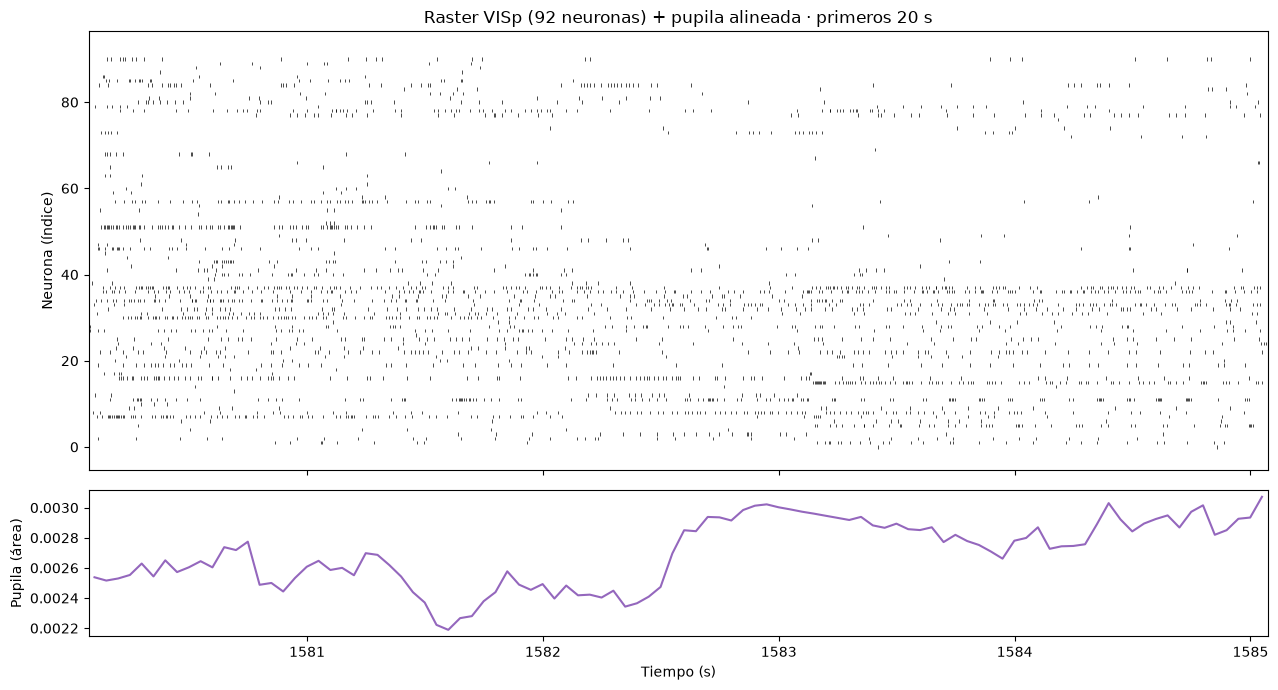

In [10]:
# Creamos dos paneles apilados que comparten el eje X (sharex=True).
# El raster ocupa 3/4 de la altura y la pupila 1/4 (gridspec_kw con height_ratios).
fig, (axr, axp) = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                               gridspec_kw={"height_ratios": [3, 1]})

# Mostramos solo los primeros 20 s para que las marcas de spikes se distingan.
t0, t1 = T_INICIO, T_INICIO + 5
# Para cada neurona, extraemos sus tiempos de spike y los recortamos a [t0, t1].
spk_win = [np.asarray(tsgroup[u].t) for u in tsgroup.keys()]
spk_win = [s[(s >= t0) & (s < t1)] for s in spk_win]

# eventplot dibuja, por cada neurona (fila), una marca vertical en cada tiempo de spike.
axr.eventplot(spk_win, colors="black", lineoffsets=np.arange(len(spk_win)),
              linelengths=0.8, linewidths=0.5)
axr.set_ylabel("Neurona (índice)")
axr.set_title(f"Raster VISp ({n_neuronas} neuronas) + pupila alineada · primeros 20 s")

# Panel inferior: la pupila en la misma ventana temporal.
sel = (tiempos >= t0) & (tiempos < t1)           # máscara de bins dentro de [t0, t1]
axp.plot(tiempos[sel], PUPILA[sel], color="tab:purple", lw=1.5)
axp.set_ylabel("Pupila (área)")
axp.set_xlabel("Tiempo (s)")
axp.set_xlim(t0, t1)
plt.tight_layout(); plt.show()

---
## Paso 2 — Reducción de dimensionalidad → **Estado Neuronal `Y`**

### La idea: de muchas neuronas a pocas "variables latentes"

Tenemos `n_neuronas` (≈ 90) tasas de disparo por instante. Pero esas neuronas **no son independientes**: comparten conexiones y entradas, así que sus actividades **covarían** fuertemente. Eso significa que la información "real" vive en muchas menos dimensiones de las que parece.

El **Análisis de Componentes Principales (PCA)** encuentra esas pocas direcciones importantes:
- **PC1** es la combinación de neuronas a lo largo de la cual la actividad **varía más**.
- **PC2** es la siguiente dirección de máxima varianza, perpendicular a PC1. Y así sucesivamente.

Proyectar la actividad sobre las 3 primeras componentes nos da el **Estado Neuronal `Y`**: una serie temporal 3D (`n_bins × 3`) que resume el comportamiento colectivo de toda la población. Ese `Y` es el **objetivo** que intentaremos predecir en el Paso 4.

### Dos detalles importantes

- **Estandarizar antes del PCA** (`StandardScaler`): ponemos cada neurona en media 0 y desviación 1. Si no, una neurona con tasa muy alta dominaría el PCA solo por su escala en Hz, no por llevar más información.
- **Ajustar solo con *train*** (rigor anti-*leakage*): definimos aquí el corte train/test (`cut`) y ajustamos el escalador **y** el PCA **usando únicamente el tramo de entrenamiento**. Luego transformamos toda la serie. Así, la propia *definición* del estado neuronal no usa información del futuro.

In [ ]:
# --- Corte temporal secuencial: primer 70 % = train, último 30 % = test ---
cut = int(FRAC_TRAIN * n_bins)                   # índice-frontera entre train y test
print(f"Train: bins [0, {cut})  |  Test: bins [{cut}, {n_bins})")

# --- Estandarizar cada neurona, AJUSTANDO SOLO CON TRAIN ---
# .fit() aprende la media y la desviación (solo de RATES[:cut]); .transform() las aplica a todo.
scaler_rates = StandardScaler().fit(RATES[:cut])
RATES_z = scaler_rates.transform(RATES)          # tasas estandarizadas (n_bins, n_neuronas)

# --- PCA, AJUSTANDO SOLO CON TRAIN ---
pca = PCA(n_components=N_COMPONENTES).fit(RATES_z[:cut])  # aprende las direcciones con el train
Y   = pca.transform(RATES_z)                     # proyecta TODO -> Estado Neuronal (n_bins, 3)

# explained_variance_ratio_ = fracción de varianza que captura cada componente.
evr = pca.explained_variance_ratio_
print(f"Estado neuronal Y: {Y.shape}  (bins x componentes)")
print(f"Varianza explicada PC1-{N_COMPONENTES}: {np.round(evr*100, 1)} %  (acumulada {evr.sum()*100:.1f} %)")

### 2.1 Visualizar el estado neuronal

Dos gráficos:
- **Izquierda (scree plot):** cuánta varianza captura cada componente. Si las primeras pocas ya explican bastante, es la prueba empírica de que la actividad es de "baja dimensión".
- **Derecha (trayectoria 3D):** cada punto es el estado de la población en un instante, situado según sus coordenadas PC1/PC2/PC3. Los unimos en orden temporal (línea gris) y **los coloreamos según el tamaño de la pupila**. Si aparecen zonas de color coherente, es una **pista visual** de que el estado neuronal se relaciona con el *arousal* — justo lo que la Tarea B intentará cuantificar.

In [ ]:
fig = plt.figure(figsize=(14, 5))

# --- Panel izquierdo: varianza explicada por componente (scree plot) ---
ax1 = fig.add_subplot(1, 2, 1)
ax1.bar(np.arange(1, len(evr)+1), evr*100, color="steelblue")   # una barra por componente
ax1.set_xlabel("Componente principal"); ax1.set_ylabel("Varianza explicada (%)")
ax1.set_title("¿Cuánta información capta cada componente?")

# --- Panel derecho: trayectoria 3D del estado, coloreada por la pupila ---
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
# scatter: un punto por instante; c=PUPILA colorea según el arousal.
p = ax2.scatter(Y[:,0], Y[:,1], Y[:,2], c=PUPILA, cmap="viridis", s=6)
ax2.plot(Y[:,0], Y[:,1], Y[:,2], color="gray", lw=0.2, alpha=0.4)   # línea = recorrido temporal
fig.colorbar(p, ax=ax2, label="Pupila (área)", shrink=0.6)
ax2.set_xlabel("PC1"); ax2.set_ylabel("PC2"); ax2.set_zlabel("PC3")
ax2.set_title("Trayectoria del Estado Neuronal (color = pupila)")
plt.tight_layout(); plt.show()

---
## Paso 3 — *Features* de la pupila → matriz **`X`** con `tsfel`

### ¿Qué es `tsfel` y qué es una *feature*?

Para el *decoding* (Tarea B) no basta con el valor puntual de la pupila en cada instante: queremos describir su **estado reciente** con más riqueza. Una *feature* (característica) es un número que resume algo de la señal en una ventana: su **media**, su **varianza**, su **pendiente** (¿está subiendo o bajando?), etc.

**`tsfel`** (*Time Series Feature Extraction Library*) automatiza esto. Funciona así:
1. Le das una **configuración** (`cfg`): un diccionario que indica qué features calcular. `tsfel.get_features_by_domain()` devuelve todas las disponibles, agrupadas por dominio (`statistical`, `temporal`, `spectral`). Cada feature tiene una marca `"use": "yes"/"no"`.
2. Le das la señal y un **tamaño de ventana**. `tsfel` desliza esa ventana por la señal y, en cada posición, calcula todas las features activas → una **fila de números por ventana**.

### Dos decisiones de diseño

- **Config compacta (rápida):** activamos solo ~12 features útiles (media, varianza, desviación, mediana, máx, mín, RMS, asimetría, y las temporales *slope*, diferencia media, área bajo la curva, autocorrelación). Menos features = más rápido, y son justo las que pide el problema (media, varianza, pendiente).
- **Ventana causal + alineación 1:1.** Queremos **una fila de features por cada bin** de `Y`, y que esa fila use **solo el pasado** (para no "ver el futuro"). Truco: rellenamos (*pad*) el inicio de la señal con `W-1` copias del primer valor. Así la ventana `k` cubre los bins `[k-W+1 .. k]` (el bin actual y los `W-1` anteriores) y produce exactamente `n_bins` filas, alineadas una a una con `Y`.

El parámetro `overlap=(W-1)/W` hace que la ventana avance **de bin en bin** (solapamiento máximo), que es lo que necesitamos para tener una feature por bin.

In [ ]:
# --- Config compacta de tsfel: activamos solo las features que nos interesan ---
WHITELIST = {
    "statistical": ["Mean", "Variance", "Standard deviation", "Median",
                    "Max", "Min", "Root mean square", "Skewness"],
    "temporal":    ["Slope", "Mean absolute diff", "Area under the curve", "Autocorrelation"],
}
cfg = tsfel.get_features_by_domain()             # dict con TODAS las features, agrupadas por dominio
# Recorremos la config y ponemos use="yes" solo a las de la whitelist; el resto, "no".
for dom in list(cfg.keys()):
    for f in cfg[dom]:
        cfg[dom][f]["use"] = "yes" if (dom in WHITELIST and f in WHITELIST[dom]) else "no"

# --- Padding causal: garantiza una fila de features por bin, usando solo el pasado ---
W = TSFEL_WIN_BINS                               # tamaño de ventana en bins (20 = 1 s)
# Añadimos W-1 copias del primer valor al inicio, para que la primera ventana "real" acabe en el bin 0.
sig_pad = np.concatenate([np.full(W-1, PUPILA[0]), PUPILA])

# --- Extracción con ventana deslizante de paso 1 ---
# fs = frecuencia de muestreo = 1/bin (20 Hz). overlap=(W-1)/W -> la ventana avanza 1 bin cada vez.
X_feat = tsfel.time_series_features_extractor(
    cfg, sig_pad, fs=1.0/TAMANO_BIN, window_size=W, overlap=(W-1)/W, verbose=0)

# --- Limpieza de la tabla de features ---
X_feat = X_feat.dropna(axis=1, how="all")        # fuera columnas totalmente vacías
X_feat = X_feat.loc[:, X_feat.std(axis=0) > 0]   # fuera columnas constantes (no aportan info)
X_feat = X_feat.fillna(0.0).reset_index(drop=True)   # NaN sueltos -> 0
X_feat = X_feat.iloc[:n_bins].reset_index(drop=True) # recorte de seguridad para cuadrar con n_bins
assert len(X_feat) == n_bins, f"Desalineación: {len(X_feat)} != {n_bins}"

X = X_feat.values.astype(float)                  # matriz numpy (n_bins, n_features)
print(f"Matriz de features X: {X.shape}  (bins x features)")
print("Features extraídas:", [c.split('_')[-1] for c in X_feat.columns])

### 3.1 Ver la pupila junto a dos de sus features

Superponemos la pupila con dos features (media móvil y pendiente móvil), re-escaladas para que quepan en el mismo gráfico. La idea es intuitiva: la **media** sigue el nivel general de la pupila, y la **pendiente** (*slope*) es positiva cuando la pupila sube y negativa cuando baja. Estas son las señales que el modelo de *decoding* usará como pistas del *arousal*.

In [ ]:
fig, ax = plt.subplots(figsize=(13, 3.5))
sel = slice(0, min(2000, n_bins))                # primeros bins (para que se vea con detalle)
ax.plot(tiempos[sel], PUPILA[sel], color="tab:purple", lw=1.2, label="Pupila (área)")
ax.set_xlabel("Tiempo (s)"); ax.set_ylabel("Pupila")
ax.set_title("Pupila y ejemplo de features de tsfel")

# Buscamos las columnas cuyo nombre contenga 'Mean' y 'Slope' y las superponemos (z-escaladas).
for key, col in [("Mean", "tab:orange"), ("Slope", "tab:green")]:
    cand = [c for c in X_feat.columns if key in c]
    if cand:
        v = X_feat[cand[0]].values[sel]
        v = (v - np.nanmean(v)) / (np.nanstd(v) + 1e-9)      # z-score para poder compararla
        # la re-escalamos al rango de la pupila solo para visualizar en el mismo eje
        ax.plot(tiempos[sel], v*np.nanstd(PUPILA[sel]) + np.nanmean(PUPILA[sel]),
                color=col, lw=1.0, alpha=0.8, label=f"{key} (reescalada)")
ax.legend(loc="upper right", fontsize=8); plt.tight_layout(); plt.show()

---
## Paso 4 — *Forecasting* avanzado (¡sin barajar los datos!)

Llegamos al núcleo. Planteamos **dos tareas** y, en cada una, comparamos **modelos** distintos.

### Las dos tareas

- **Tarea A — Forecasting autoregresivo.** *Autoregresivo* significa "predecir el futuro de una señal a partir de su propio pasado". Aquí: predecir el estado neuronal futuro `Y[t+h]` usando los `AR_LAGS` bins pasados de `Y`. Lo hacemos a tres **horizontes** `h = 1, 5, 10` bins (50, 250 y 500 ms al futuro). Esperamos que **cuanto más lejos** miremos, **peor** sea la predicción.
- **Tarea B — *Decoding* desde la pupila.** Predecir el estado neuronal **actual** `Y[t]` a partir de las features de pupila `X[t]`. Mide cuánto del estado cortical está "explicado" por el nivel de *arousal*.

### Los modelos

- 🟦 **`nemos` GLM (baseline).** Un **GLM** (*Generalized Linear Model*) es un modelo lineal: predice combinando linealmente las entradas. `nemos` los implementa sobre **JAX**, así que son muy rápidos. Usamos la variante **gaussiana** (apropiada para un objetivo continuo con signo como los PCs) y **regularización Ridge** (penaliza pesos grandes para evitar sobreajuste). Como cada GLM predice **un** número, entrenamos **uno por componente** de `Y`.
- 🟥 **GRU (`torch`, avanzado).** Una **GRU** (*Gated Recurrent Unit*) es un tipo de **red neuronal recurrente**: procesa una secuencia paso a paso manteniendo un "estado oculto" (una memoria) que resume lo visto. Es ideal para dinámica temporal no lineal. Entrena en la GPU.
- 🟨 **`XGBoost` (extra).** *Gradient boosting* de árboles: construye muchos árboles de decisión pequeños que se corrigen entre sí. Muy potente en datos tabulares; lo usamos como comparativa no lineal en la Tarea B.

### La métrica: R²

El **R²** (coeficiente de determinación) mide qué fracción de la varianza del objetivo explica el modelo:
- **R² = 1** → predicción perfecta.
- **R² = 0** → el modelo no predice mejor que decir siempre "la media".
- **R² < 0** → peor que la media (modelo malo para esos datos).

Primero definimos las **utilidades comunes**: escalado *train-only*, construcción de las muestras supervisadas (respetando la frontera temporal para no hacer trampa) y el entrenamiento de la GRU.

In [ ]:
# ============================================================
#  UTILIDADES COMUNES  (se explican una a una)
# ============================================================

def z_train(arr, cut):
    # Estandariza 'arr' (media 0, desv 1) APRENDIENDO los parámetros SOLO del tramo train [0, cut).
    # Devuelve el array transformado y el escalador (por si hiciera falta invertir).
    sc = StandardScaler().fit(arr[:cut])
    return sc.transform(arr), sc

def indices_supervisados(n, P, h, cut):
    # Genera los índices 'ancla' i para construir muestras (entrada -> objetivo).
    #   entrada = bins [i-P+1 .. i]  (P bins de historia, terminando en i)
    #   objetivo = bin (i+h)          (lo que queremos predecir, h bins al futuro)
    # Reparto SIN fuga de información:
    #   - va a TRAIN si el objetivo cae en train:            i+h  <  cut
    #   - va a TEST  si toda la entrada cae en test:          i-P+1 >= cut
    #   - se DESCARTAN las muestras que cruzan la frontera (para que test no vea train).
    tr, te = [], []
    for i in range(P-1, n-h):
        if   i + h < cut:          tr.append(i)
        elif i - P + 1 >= cut:     te.append(i)
    return np.array(tr), np.array(te)

def construir_plano(src, tgt, P, h, cut):
    # Formato "plano" para GLM y XGBoost: aplana los P bins de historia en un solo vector de features.
    #   src = fuente de las entradas (p. ej. Y en la Tarea A, o X en la B)
    #   tgt = objetivo a predecir (siempre Y aquí)
    tr, te = indices_supervisados(len(src), P, h, cut)
    def feats(idx):
        # Para cada ancla i, toma src[i-P+1 .. i] y lo aplana a un vector 1D (reshape(-1)).
        return np.stack([src[i-P+1:i+1].reshape(-1) for i in idx])
    return feats(tr), tgt[tr+h], feats(te), tgt[te+h]

def construir_secuencias(src, tgt, P, h, cut):
    # Formato "secuencia" para la GRU: mantiene la forma 3D (muestras, pasos_de_tiempo, features).
    tr, te = indices_supervisados(len(src), P, h, cut)
    def seqs(idx):
        return np.stack([src[i-P+1:i+1] for i in idx])   # cada muestra es (P, n_features)
    return seqs(tr), tgt[tr+h], seqs(te), tgt[te+h]

class GRURegresor(nn.Module):
    # Definición de la red: una GRU seguida de una capa lineal.
    def __init__(self, n_in, n_hidden, n_out):
        super().__init__()
        # nn.GRU procesa la secuencia; batch_first=True -> entrada con forma (muestras, pasos, features).
        self.gru = nn.GRU(n_in, n_hidden, batch_first=True)
        # nn.Linear convierte el estado oculto final en la predicción (n_out valores = 3 PCs).
        self.fc  = nn.Linear(n_hidden, n_out)
    def forward(self, x):
        out, _ = self.gru(x)          # 'out' contiene el estado oculto en cada paso de tiempo
        return self.fc(out[:, -1, :]) # tomamos SOLO el último paso (resumen de toda la secuencia)

def entrenar_gru(Xtr, Ytr, Xte, n_in, n_out, hidden=GRU_HIDDEN,
                 epochs=GRU_EPOCHS, lr=GRU_LR, batch=GRU_BATCH):
    # Entrena la GRU y devuelve sus predicciones sobre el conjunto de test (como numpy).
    torch.manual_seed(SEED)                                   # reproducibilidad
    model = GRURegresor(n_in, n_hidden=hidden, n_out=n_out).to(DEVICE)  # crea el modelo en GPU/CPU
    opt   = torch.optim.Adam(model.parameters(), lr=lr)       # optimizador (ajusta los pesos)
    lossf = nn.MSELoss()                                      # pérdida: error cuadrático medio

    # Convertimos los datos a tensores de torch y los movemos al dispositivo (GPU/CPU).
    Xt = torch.tensor(Xtr, dtype=torch.float32, device=DEVICE)
    Yt = torch.tensor(Ytr, dtype=torch.float32, device=DEVICE)
    n  = Xt.shape[0]

    model.train()                                             # modo entrenamiento
    for _ in range(epochs):                                   # cada época = una pasada por los datos
        perm = torch.randperm(n, device=DEVICE)               # barajamos el ORDEN de las muestras...
        # ...(NO el tiempo interno de cada secuencia: eso se respeta). Esto solo mejora el entrenamiento.
        for k in range(0, n, batch):                          # recorremos en mini-lotes
            idx = perm[k:k+batch]
            opt.zero_grad()                                   # 1) resetea gradientes
            loss = lossf(model(Xt[idx]), Yt[idx])             # 2) predice y calcula el error
            loss.backward()                                   # 3) backpropagation (calcula gradientes)
            opt.step()                                        # 4) actualiza los pesos

    model.eval()                                              # modo evaluación
    with torch.no_grad():                                     # sin gradientes (más rápido)
        pred = model(torch.tensor(Xte, dtype=torch.float32, device=DEVICE)).cpu().numpy()
    return pred

def glm_multisalida(Xtr, Ytr, Xte):
    # nemos GLM predice UN escalar; para las 3 componentes de Y entrenamos 3 GLMs y apilamos.
    preds = []
    for j in range(Ytr.shape[1]):                             # una componente (PC) por iteración
        glm = nmo.glm.GLM(observation_model="Gaussian",       # objetivo continuo -> gaussiano
                          regularizer="Ridge",                # regularización L2 (anti-sobreajuste)
                          regularizer_strength=1.0)
        glm.fit(Xtr, Ytr[:, j])                               # entrena con la columna j
        preds.append(np.asarray(glm.predict(Xte)))            # predice test (jax -> numpy)
    return np.stack(preds, axis=1)                            # (n_test, 3)

def r2_por_componente(y_true, y_pred):
    # R² de cada componente por separado ('raw_values') y su media.
    r2s = r2_score(y_true, y_pred, multioutput="raw_values")
    return r2s, float(np.mean(r2s))

print("Utilidades listas ✅")

### 4.A — Tarea A: *Forecasting* autoregresivo del estado neuronal

Para cada horizonte `h` construimos las muestras "entrada = pasado de `Y` → objetivo = `Y[t+h]`" y comparamos GLM vs GRU.

Nota sobre `Yz`: estandarizamos `Y` con parámetros del *train*. Esto ayuda a que la GRU entrene de forma estable. El **R² no cambia** por esta transformación (es invariante a escalar/desplazar por igual predicción y objetivo), así que las métricas siguen siendo comparables e interpretables.

In [ ]:
# Estandarizamos el estado neuronal (train-only). scY guardaría los parámetros si quisiéramos invertir.
Yz, scY = z_train(Y, cut)

# Diccionarios donde acumularemos resultados y predicciones para los gráficos del Paso 5.
resultados_A = {"horizonte": [], "GLM (nemos)": [], "GRU (torch)": []}
detalle_A = {}

for h in AR_HORIZONTES:                                        # recorremos cada horizonte
    # --- GLM: features = AR_LAGS bins pasados de Y (aplanados) ---
    Xtr, Ytr, Xte, Yte = construir_plano(Yz, Yz, P=AR_LAGS, h=h, cut=cut)
    pred_glm = glm_multisalida(Xtr, Ytr, Xte)                 # predicción del GLM en test
    _, r2_glm = r2_por_componente(Yte, pred_glm)              # R² medio sobre las 3 componentes

    # --- GRU: mismas muestras pero en formato secuencia (P bins x 3 PCs) ---
    Xtr_s, Ytr_s, Xte_s, Yte_s = construir_secuencias(Yz, Yz, P=AR_LAGS, h=h, cut=cut)
    pred_gru = entrenar_gru(Xtr_s, Ytr_s, Xte_s, n_in=N_COMPONENTES, n_out=N_COMPONENTES)
    _, r2_gru = r2_por_componente(Yte_s, pred_gru)

    # Guardamos métricas y predicciones.
    resultados_A["horizonte"].append(h)
    resultados_A["GLM (nemos)"].append(r2_glm)
    resultados_A["GRU (torch)"].append(r2_gru)
    detalle_A[h] = {"y_true": Yte_s, "pred_glm": pred_glm, "pred_gru": pred_gru}
    print(f"h={h:2d} bins ({h*TAMANO_BIN*1000:.0f} ms)  ->  R² GLM={r2_glm:+.3f} | R² GRU={r2_gru:+.3f}")

df_A = pd.DataFrame(resultados_A)                             # tabla-resumen de la Tarea A
df_A

### 4.B — Tarea B: *Decoding* del estado neuronal desde la pupila

Ahora la entrada es la **pupila** y el objetivo el estado neuronal **actual** (`h=0`). Comparamos tres modelos:
- **GLM** y **XGBoost** usan la feature del **instante actual** `X[t]` (`P=1`).
- La **GRU** usa una **secuencia** de `DEC_SEQ` bins (1 s) de features de pupila, para aprovechar la dinámica reciente del *arousal*.

In [ ]:
# Estandarizamos las features de pupila (train-only).
Xz, scX = z_train(X, cut)

# --- GLM y XGBoost: entrada = X[t] (P=1, h=0) -> Y[t] ---
Xtr, Ytr, Xte, Yte = construir_plano(Xz, Yz, P=1, h=0, cut=cut)

# GLM gaussiano (uno por componente).
pred_glm_B = glm_multisalida(Xtr, Ytr, Xte)
_, r2_glm_B = r2_por_componente(Yte, pred_glm_B)

# XGBoost: un regresor de árboles por componente. Hiperparámetros moderados (rápido y robusto).
pred_xgb_B = np.stack([
    XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                 subsample=0.9, tree_method="hist").fit(Xtr, Ytr[:, j]).predict(Xte)
    for j in range(N_COMPONENTES)], axis=1)
_, r2_xgb_B = r2_por_componente(Yte, pred_xgb_B)

# --- GRU: secuencia de DEC_SEQ bins de features de pupila -> Y[t] ---
Xtr_s, Ytr_s, Xte_s, Yte_s = construir_secuencias(Xz, Yz, P=DEC_SEQ, h=0, cut=cut)
pred_gru_B = entrenar_gru(Xtr_s, Ytr_s, Xte_s, n_in=Xz.shape[1], n_out=N_COMPONENTES)
_, r2_gru_B = r2_por_componente(Yte_s, pred_gru_B)

df_B = pd.DataFrame({"Modelo": ["GLM (nemos)", "XGBoost", "GRU (torch)"],
                     "R² (media 3 PCs)": [r2_glm_B, r2_xgb_B, r2_gru_B]})
print("Decoding pupila -> estado neuronal (R² en test):")
df_B

---
## Paso 5 — Evaluación visual

Dos visualizaciones que resumen todo el trabajo:

1. **R² por horizonte (Tarea A):** confirma (o no) nuestra hipótesis de que predecir más lejos en el futuro es más difícil. La curva debería **descender** al aumentar `h`.
2. **Trayectoria `Y` real vs predicho (Tarea B):** el "wow factor" geométrico. Dibujamos en el espacio de componentes principales la trayectoria **real** del estado neuronal (negro) y la **reconstruida** por el modelo solo a partir de la pupila (rojo). Cuanto más se parezcan, mejor el *decoding*.

In [ ]:
# --- (1) R² vs horizonte (Tarea A): GLM vs GRU ---
fig, ax = plt.subplots(figsize=(8, 5))
hh = df_A["horizonte"].values
ax.plot(hh, df_A["GLM (nemos)"], "o-", color="tab:blue", lw=2, ms=9, label="GLM (nemos)")
ax.plot(hh, df_A["GRU (torch)"], "s-", color="tab:red",  lw=2, ms=9, label="GRU (torch)")
ax.axhline(0, color="gray", ls="--", lw=1)                   # línea R²=0 (referencia: predecir la media)
ax.set_xlabel("Horizonte de predicción h (bins)")
ax.set_ylabel("R²  (media de los 3 PCs, en test)")
ax.set_title("Tarea A · Forecasting autoregresivo: R² vs horizonte")
ax.set_xticks(hh)
ax.set_xticklabels([f"{h}\n({h*TAMANO_BIN*1000:.0f} ms)" for h in hh])
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [ ]:
# --- (2) Trayectoria real vs predicho (Tarea B, decoding con la GRU) ---
n_ver = min(400, len(Yte_s))                                 # primer tramo de test (para verlo limpio)
yt = Yte_s[:n_ver]                                           # estado real
yp = pred_gru_B[:n_ver]                                      # estado predicho por la GRU

fig = plt.figure(figsize=(14, 6))

# 2D: PC1 vs PC2
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(yt[:,0], yt[:,1], color="black",   lw=1.5, alpha=0.8, label="Real")
ax1.plot(yp[:,0], yp[:,1], color="tab:red", lw=1.5, alpha=0.8, label="Predicho (GRU)")
ax1.set_xlabel("PC1"); ax1.set_ylabel("PC2")
ax1.set_title("Tarea B · Trayectoria 2D: estado real vs predicho")
ax1.legend()

# 3D: PC1, PC2, PC3
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.plot(yt[:,0], yt[:,1], yt[:,2], color="black",   lw=1.2, alpha=0.8, label="Real")
ax2.plot(yp[:,0], yp[:,1], yp[:,2], color="tab:red", lw=1.2, alpha=0.8, label="Predicho (GRU)")
ax2.set_xlabel("PC1"); ax2.set_ylabel("PC2"); ax2.set_zlabel("PC3")
ax2.set_title("Tarea B · Trayectoria 3D")
ax2.legend()
plt.tight_layout(); plt.show()

# --- Serie temporal de PC1: real vs cada modelo (otra forma de ver la calidad del decoding) ---
fig, ax = plt.subplots(figsize=(13, 3.8))
ax.plot(yt[:,0], color="black", lw=1.8, label="Real")
ax.plot(pred_glm_B[:n_ver,0], color="tab:blue", lw=1.0, alpha=0.8, label="GLM (nemos)")
ax.plot(yp[:,0],              color="tab:red",  lw=1.0, alpha=0.8, label="GRU (torch)")
ax.set_xlabel("Bin de test"); ax.set_ylabel("PC1 (estado neuronal)")
ax.set_title("Tarea B · PC1 en el tiempo: real vs modelos")
ax.legend(ncol=3); plt.tight_layout(); plt.show()

---
## Conclusiones y siguientes pasos

**Qué hemos construido, en cinco pasos:**
1. Un pipeline de **streaming** que alinea **spikes de VISp** y **pupila** en una base temporal común con `pynapple`.
2. Un **estado neuronal `Y`** de baja dimensión mediante PCA (ajustado *train-only*).
3. Una matriz de features `X` de la pupila con `tsfel` (media, varianza, *slope*…).
4. **Forecasting** con dos paradigmas: **GLM gaussiano acelerado** (`nemos`/JAX) y **GRU** (`torch`, GPU), más **XGBoost** como comparativa.
5. Evaluación honesta con *split* **secuencial** (sin *shuffle*) y R² en test.

**Cómo leer los resultados:**
- La **Tarea A** cuantifica la *memoria* del sistema: si el R² **cae** al aumentar el horizonte, confirma que la dinámica neuronal es predecible a corto plazo y se vuelve incierta a largo. Si la **GRU** supera al **GLM**, hay dinámica **no lineal** que el modelo lineal no captura.
- La **Tarea B** cuantifica el acoplamiento **arousal → estado cortical**: un R² positivo indica que la pupila (estado interno) modula de forma reconstruible el estado poblacional de VISp. Es un resultado bien documentado en la literatura (el estado de alerta modula la corteza visual).

**Extensiones para la siguiente iteración del hackathon:**
- Probar modelos específicos de neurociencia sobre PyTorch con **`torch_brain`** (p. ej. POYO) para *forecasting* de poblaciones.
- Añadir la señal de *running* (rueda de correr) como covariable extra del estado.
- Ajustar hiperparámetros de la GRU con **validación temporal** (*rolling-origin cross-validation*).
- Comparar la predictibilidad entre regiones (VISp vs VISl vs LGd) cambiando `REGION_OBJETIVO`.

In [ ]:
# Buenas prácticas: cerramos la conexión de streaming para liberar recursos.
# Es importante sobre todo en Windows. Cerramos en orden inverso a la apertura.
io.close()          # cierra el lector NWB
h5_file.close()     # cierra el archivo HDF5
rem_file.close()    # cierra la conexión remota
print("Archivo NWB cerrado. Recursos liberados.")